# Average Shortest Paths Simple Trading Strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt

warnings.filterwarnings('ignore')

**Strategy**
- When the positive average shortest paths is higher than the negative average shortest paths buy/hold. Otherwise sell.
- Will start with $1000 for each stock.
- Buying will use up all capital for that stock and selling will sell all units of a stock.

In [2]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK=3
SPLIT_DATE = "2021-01-01"

In [3]:
avsp = pd.read_csv(f'./data/all_avsp_crsp_window_{LOOKBACK}.csv')
avsp[DATE_COL] = pd.to_datetime(avsp[DATE_COL])
avsp = avsp[avsp[DATE_COL] >= SPLIT_DATE].reset_index(drop=True)
avsp.head()

,dlycaldt,permno,ticker,dlyclose,tot_shares,pos,neg,true_prc
0,2021-01-04,10026,JJSF,152.23,18956.0,1.333333,1.000000,2.885672
1,2021-01-05,10026,JJSF,149.92,18956.0,1.000000,1.333333,2.841884
2,2021-01-06,10026,JJSF,153.47,18956.0,1.000000,1.333333,2.909177
3,2021-01-07,10026,JJSF,154.35,18956.0,1.333333,1.000000,2.925859
4,2021-01-08,10026,JJSF,154.44,18956.0,1.333333,1.000000,2.927565


##### Initial Exploration

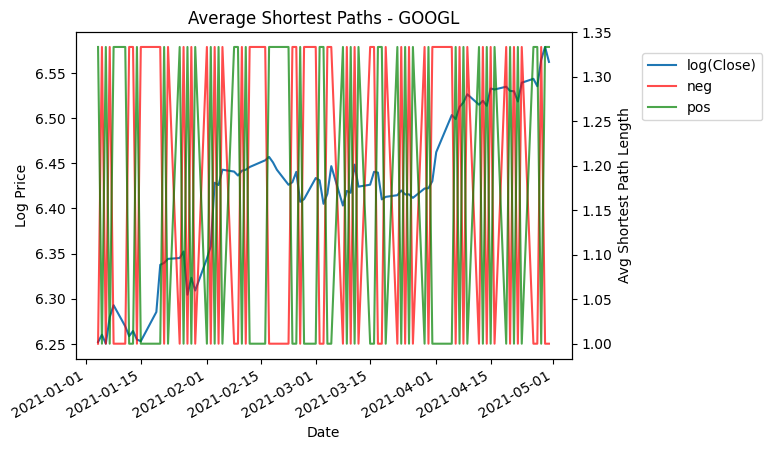

In [14]:
ticker2 = "GOOGL"
df = avsp[(avsp[TICKER_COL2] == ticker2)]
df = df[df[DATE_COL] <= '2021-05-01'].reset_index(drop=True)
df = df.set_index(DATE_COL)

fig, ax1 = plt.subplots()

ax1.plot(np.log(df[NUM_COL]), label="log(Close)")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left", bbox_to_anchor=(1, 0.85))
plt.title(f"Average Shortest Paths - {df['ticker'].values[0]}")
plt.xticks(rotation=45)
ax1.set_xlabel('Date')
fig.autofmt_xdate() 
plt.show()

In [15]:
curr_b = START_BALANCE
curr_vol = 0
### Full Exit
exit_prop = EXIT_PROP
returns = []

for _, row in df.iterrows():

    pos = row['pos']
    neg = row['neg']
    num = row[NUM_COL]

    # Buy signal
    if pos >= neg:
        ### Only buy if we have balance
        ### Otherwise we will just be holding the stock
        if curr_b > 0:
            curr_vol += curr_b / num
            curr_b = 0

    # Sell signal
    else:
        ### Only sell if we have volume to sell
        if curr_vol > 0:
            shares_sold = exit_prop * curr_vol
            curr_b += shares_sold * num
            curr_vol -= shares_sold
            
    ### Current Return of the Strategy
    ### Cash Balance + Value of Held Stock
    returns.append(curr_b + curr_vol * num)

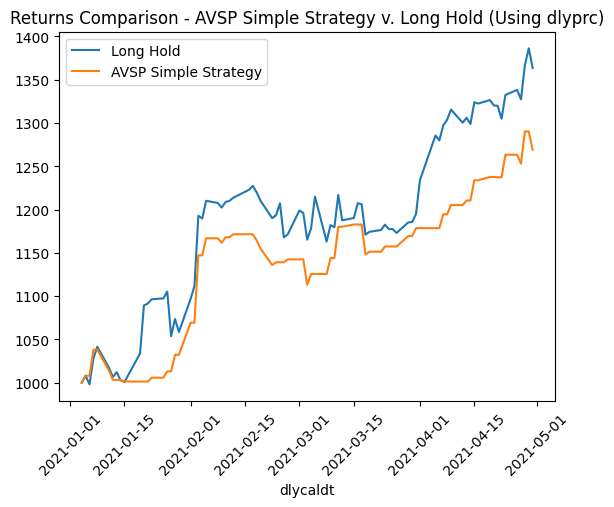

In [16]:
start_vol = START_BALANCE / df['dlyclose'].iloc[0]

hold_ret = start_vol * df['dlyclose'].values * (18.51)**(df.index > dt.datetime(year=2022, day=15, month=7))

df['hold_ret1'] = hold_ret

sns.lineplot(x=df.index, y=hold_ret, label="Long Hold")
sns.lineplot(x=df.index, y=returns, label="AVSP Simple Strategy")

plt.title("Returns Comparison - AVSP Simple Strategy v. Long Hold (Using dlyprc)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

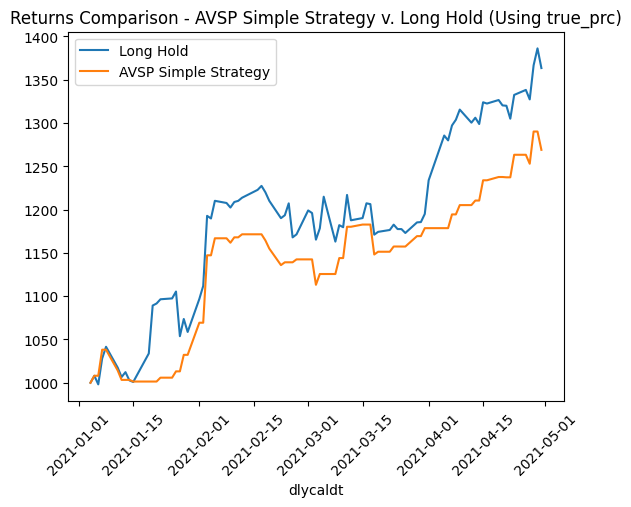

In [17]:
start_vol = START_BALANCE / df[NUM_COL].iloc[0]

hold_ret = start_vol * df[NUM_COL].values

df['hold_ret2'] = hold_ret

sns.lineplot(x=df.index, y=hold_ret, label="Long Hold")
sns.lineplot(x=df.index, y=returns, label="AVSP Simple Strategy")

plt.title("Returns Comparison - AVSP Simple Strategy v. Long Hold (Using true_prc)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Function Development

In [20]:
def avsp_simple_strat_single(df, curr_b=1000, exit_prop=1.0):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pos = row['pos']
        neg = row['neg']
        num = row[NUM_COL]

        ### Buy signal
        if pos >= neg:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [21]:
def avsp_simple_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = avsp_simple_strat_single(df, curr_b=curr_b, exit_prop=exit_prop)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    
    return ret_df

In [22]:
data = avsp.copy()
filename = f"./data/all_avsp_simple_test_rets_window_{LOOKBACK}.csv"
tickers = data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().values
ret_df = avsp_simple_strat(data, tickers)
ret_df.to_csv(filename, index=False)

# ret_df = pd.read_csv(filename)
# ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

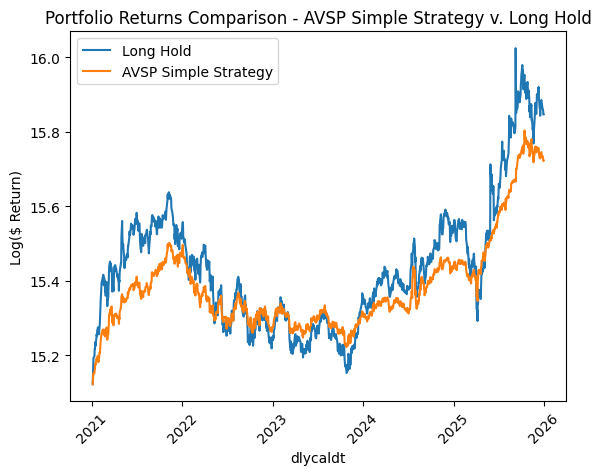

In [23]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"})

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

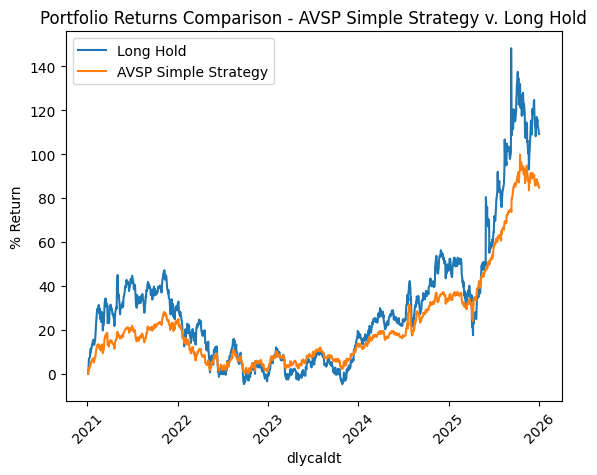

In [24]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"})
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="AVSP Simple Strategy")

plt.title("Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

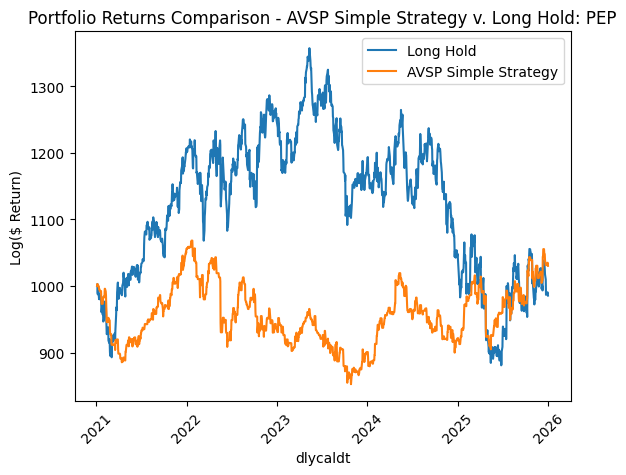

In [25]:
t = "PEP"
plot_df = ret_df[ret_df['ticker'] == t]

sns.lineplot(x=plot_df[DATE_COL], y=plot_df['hold_ret'], label="Long Hold")
sns.lineplot(x=plot_df[DATE_COL], y=plot_df['strat_ret'], label="AVSP Simple Strategy")

plt.title(f"Portfolio Returns Comparison - AVSP Simple Strategy v. Long Hold: {t}")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

#### Get Trading Signals

In [10]:
avsp = pd.read_csv(f'./data/all_avsp_crsp_window_{LOOKBACK}.csv')
avsp[DATE_COL] = pd.to_datetime(avsp[DATE_COL])
avsp = avsp[avsp[DATE_COL] < SPLIT_DATE].reset_index(drop=True)

avsp = avsp.sort_values([TICKER_COL1, DATE_COL]).copy()

avsp["target"] = (
    avsp.groupby(TICKER_COL1)[NUM_COL]
    .shift(-1)
)

avsp = avsp.dropna(subset=["target"]).reset_index(drop=True)
avsp['pred'] = (avsp['pos'] >= avsp['neg']).astype(int)
avsp['signal'] = avsp['pred']
avsp = avsp[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target", "pred", "signal"]]
avsp.to_csv(f'./data/all_avsp_simple_train_preds_window_{LOOKBACK}.csv', index=False)

In [9]:
avsp = pd.read_csv(f'./data/all_avsp_crsp_window_{LOOKBACK}.csv')
avsp[DATE_COL] = pd.to_datetime(avsp[DATE_COL])
avsp = avsp[avsp[DATE_COL] >= SPLIT_DATE].reset_index(drop=True)

avsp = avsp.sort_values([TICKER_COL1, DATE_COL]).copy()

avsp["target"] = (
    avsp.groupby(TICKER_COL1)[NUM_COL]
    .shift(-1)
)

avsp = avsp.dropna(subset=["target"]).reset_index(drop=True)
avsp['pred'] = (avsp['pos'] >= avsp['neg']).astype(int)
avsp['signal'] = avsp['pred']
avsp = avsp[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target", "pred", "signal"]]
avsp.to_csv(f'./data/all_avsp_simple_test_preds_window_{LOOKBACK}.csv', index=False)